
# Model Development
    

## Objectives

After completing this lab you will be able to:

* Develop prediction models


<p>In this section, we will develop several models that will predict the price of the car using the variables or features. This is just an estimate but should give us an objective idea of how much the car should cost.</p>


Some questions we want to ask in this module
<ul>
    <li>Do I know if the dealer is offering fair value for my trade-in?</li>
    <li>Do I know if I put a fair value on my car?</li>
</ul>
<p>In data analytics, we often use <b>Model Development</b> to help us predict future observations from the data we have.</p>

<p>A model will help us understand the exact relationship between different variables and how these variables are used to predict the result.</p>


<h4>Setup</h4>


 Import libraries:


```text
#install specific version of libraries used in lab
#! mamba install pandas==1.3.3-y
#! mamba install numpy=1.21.2-y
#! mamba install sklearn=0.20.1-y
```

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Load the data and store it in dataframe `df`:


In [19]:
import requests
import os

def download_data(url ,filename):
    os.makedirs("data", exist_ok=True)
    filepath = os.path.join("data", filename)
    response = requests.get(url)
    if response.status_code == 200:
        with open(filepath, 'wb') as file:
            file.write(response.content)
        print("Data downloaded and saved successfully.")
    else:
        print("Failed to download data.")


In [20]:
file_path= "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-SkillsNetwork/labs/Data%20files/automobileEDA.csv"

download_data(file_path, "usedcars.csv")
file_name="data/usedcars.csv"

Data downloaded and saved successfully.


In [21]:
df = pd.read_csv(file_name)
df.head()

,symboling,normalized-losses,make,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,...,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,horsepower-binned,diesel,gas
0,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,0.811148,...,9.0,111.0,5000.0,21,27,13495.0,11.190476,Medium,0,1
1,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,0.811148,...,9.0,111.0,5000.0,21,27,16500.0,11.190476,Medium,0,1
2,1,122,alfa-romero,std,two,hatchback,rwd,front,94.5,0.822681,...,9.0,154.0,5000.0,19,26,16500.0,12.368421,Medium,0,1
3,2,164,audi,std,four,sedan,fwd,front,99.8,0.848630,...,10.0,102.0,5500.0,24,30,13950.0,9.791667,Medium,0,1
4,2,164,audi,std,four,sedan,4wd,front,99.4,0.848630,...,8.0,115.0,5500.0,18,22,17450.0,13.055556,Medium,0,1


<h2>1. Linear Regression and Multiple Linear Regression</h2>


<h4>Linear Regression</h4>



<p>One example of a Data  Model that we will be using is:</p>
<b>Simple Linear Regression</b>

<br>
<p>Simple Linear Regression is a method to help us understand the relationship between two variables:</p>
<ul>
    <li>The predictor/independent variable (X)</li>
    <li>The response/dependent variable (that we want to predict)(Y)</li>
</ul>

<p>The result of Linear Regression is a <b>linear function</b> that predicts the response (dependent) variable as a function of the predictor (independent) variable.</p>



$$
 Y: Response \ Variable\\\\\\
 X: Predictor \ Variables
$$


 <b>Linear Function</b>
$$
Yhat = a + b  X
$$


<ul>
    <li>a refers to the <b>intercept</b> of the regression line, in other words: the value of Y when X is 0</li>
    <li>b refers to the <b>slope</b> of the regression line, in other words: the value with which Y changes when X increases by 1 unit</li>
</ul>


Think of the regression line as a straight line that predicts **Y** from **X**.

The equation is:

$$
Y = a + bX
$$

Where:

- **a** = **Intercept**
- **b** = **Slope**

#### What does the Intercept (`a`) mean?

The **intercept** is the value of **Y when X = 0**.

In simple words:

> **If X starts at 0, the regression line starts at \(Y = a\).**

##### Example 1

Suppose the regression equation is:

$$
Y = 5 + 2X
$$

If **X = 0**:

$$
Y = 5 + 2(0) = 5
$$

So, **5 is the intercept**.

This means the regression line crosses the **Y-axis** at **5**.

##### Example 2 (Real-Life)

Imagine:

- **X** = Hours Studied
- **Y** = Exam Score

Regression equation:

$$
\text{Score} = 20 + 10 \times (\text{Hours Studied})
$$

If a student studies **0 hours**:

$$
\text{Score} = 20 + 10(0) = 20
$$

Here:

- **20** is the **intercept**.
- It represents the **starting score before any studying**.

#### Easy Way to Remember 

- **Intercept** = Starting point of the line (when **X = 0**)
- **Slope** = How much **Y** changes when **X** increases by **1**

#### Summary

The statement:

> **"a refers to the intercept of the regression line, in other words: the value of Y when X is 0."**

Simply means:

> **`a` is the starting value of `Y` before `X` has any effect (i.e., when `X = 0`).**

<h4>Let's load the modules for linear regression:</h4>


In [22]:
from sklearn.linear_model import LinearRegression

<h4>Create the linear regression object:</h4>


In [23]:
lm = LinearRegression()
lm

LinearRegression()

<h4>How could "highway-mpg" help us predict car price?</h4>


For this example, we want to look at how highway-mpg can help us predict car price.
Using simple linear regression, we will create a linear function with "highway-mpg" as the predictor variable and the "price" as the response variable.


In [24]:
X = df[["highway-mpg"]]
Y = df["price"]

Fit the linear model using highway-mpg:


In [25]:
lm.fit(X,Y)

LinearRegression()

 We can output a prediction:


In [26]:
Yhat = lm.predict(X)
Yhat[0:5]

array([16236.50464347, 16236.50464347, 17058.23802179, 13771.3045085 ,
       20345.17153508])

In [27]:
result = pd.DataFrame({
    "Index" : df.index[0:5], 
    "Highway MPG" : df["highway-mpg"][0:5],
    "Actual Price" : df["price"][0:5],
    "Predicted Price" : Yhat[0:5]
})

In [28]:
result.head()

,Index,Highway MPG,Actual Price,Predicted Price
0,0,27,13495.0,16236.504643
1,1,27,16500.0,16236.504643
2,2,26,16500.0,17058.238022
3,3,30,13950.0,13771.304508
4,4,22,17450.0,20345.171535


<h4>What is the value of the intercept (a)?</h4>


In [29]:
lm.intercept_

38423.3058581574

<h4>What is the value of the slope (b)?</h4>


In [30]:
lm.coef_

array([-821.73337832])

<h3>What is the final estimated linear model we get?</h3>


As we saw above, we should get a final linear model with the structure:


$$
Yhat = a + b  X
$$


Plugging in the actual values we get:


<b>Price</b> = 38423.31 - 821.73 x <b>highway-mpg</b>


Create a linear regression object called "lm1".

In [31]:
lm1 = LinearRegression()

In [32]:
df.columns

Index(['symboling', 'normalized-losses', 'make', 'aspiration', 'num-of-doors',
       'body-style', 'drive-wheels', 'engine-location', 'wheel-base', 'length',
       'width', 'height', 'curb-weight', 'engine-type', 'num-of-cylinders',
       'engine-size', 'fuel-system', 'bore', 'stroke', 'compression-ratio',
       'horsepower', 'peak-rpm', 'city-mpg', 'highway-mpg', 'price',
       'city-L/100km', 'horsepower-binned', 'diesel', 'gas'],
      dtype='object')

In [33]:
X = df[["engine-size"]]
Y = df["price"]

In [34]:
lm1.fit(X, Y)

LinearRegression()

In [35]:
lm1.coef_

array([166.86001569])

In [36]:
lm1.intercept_

-7963.338906281027

```text
 Y = a + bX
 ```

price = -7963.33 + 166.86 x engine_size

<p> Prediction on full dataset</p>

In [37]:
Yhat_full = lm1.predict(X)
result_full = pd.DataFrame({
    "index" : df.index,
    "engine_size" : df["engine-size"],
    "price" : df["price"],
    "predicted_price" : Yhat_full
})
result_full.head(10)

,index,engine_size,price,predicted_price
0,0,130,13495.0,13728.463134
1,1,130,16500.0,13728.463134
2,2,152,16500.0,17399.383479
3,3,109,13950.0,10224.402804
4,4,136,17450.0,14729.623228
5,5,136,15250.0,14729.623228
6,6,136,17710.0,14729.623228
7,7,136,18920.0,14729.623228
8,8,131,23875.0,13895.323149
9,9,108,16430.0,10057.542788


<p>Model Evaluvation</p>

In [38]:
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(Y, Yhat_full)
r2 = r2_score(Y, Yhat_full)
print(mse)
print(r2)

15021126.02517414
0.7609686443622008


#### Model Evaluation Interpretation

##### Mean Squared Error (MSE)

**Value:** `15,021,126.03`

- Mean Squared Error (MSE) measures the average squared difference between the **actual** and **predicted** values.
- A value of **15,021,126.03** means that, on average, the squared prediction error is approximately **15 million price units²**.
- Because the errors are **squared**, larger prediction errors receive much greater penalties than smaller ones.
- **Lower MSE values indicate better model performance.**
- The magnitude of MSE depends on the scale of the target variable (`price`), so it is mainly useful for comparing different models trained on the same dataset.

---

##### R-squared (R² Score)

**Value:** `0.76097` (≈ **76.10%**)

- The R² score measures the proportion of the variance in the target variable that is explained by the model.
- An R² value of **0.76097** indicates that the linear regression model explains approximately **76.10%** of the variation in automobile prices.
- The remaining **23.90%** of the variation is due to factors not captured by the model or random error.
- Since the R² value is relatively close to **1**, the model provides a **good fit** to the data.

---

##### Overall Interpretation

The linear regression model demonstrates **good predictive performance**. The **R² score of 0.76097** indicates that approximately **76.10% of the variability in automobile prices** is explained by the model, suggesting a strong relationship between the predictor(s) and the target variable. The **MSE of 15,021,126.03** represents the average squared prediction error; although its value appears large, this is expected because automobile prices are measured in large monetary units and MSE squares the errors. Overall, the model captures most of the price variation, but there is still room for improvement by incorporating additional relevant features or using more advanced regression techniques.

<h4>Multiple Linear Regression</h4>


<p>What if we want to predict car price using more than one variable?</p>

<p>If we want to use more variables in our model to predict car price, we can use <b>Multiple Linear Regression</b>.
Multiple Linear Regression is very similar to Simple Linear Regression, but this method is used to explain the relationship between one continuous response (dependent) variable and <b>two or more</b> predictor (independent) variables.
Most of the real-world regression models involve multiple predictors. We will illustrate the structure by using four predictor variables, but these results can generalize to any integer:</p>


$$
Y: Response \ Variable\\\\\\
X_1 :Predictor\ Variable \ 1\\
X_2: Predictor\ Variable \ 2\\
X_3: Predictor\ Variable \ 3\\
X_4: Predictor\ Variable \ 4\\
$$


$$
a: intercept\\\\\\
b_1 :coefficients \ of\ Variable \ 1\\
b_2: coefficients \ of\ Variable \ 2\\
b_3: coefficients \ of\ Variable \ 3\\
b_4: coefficients \ of\ Variable \ 4\\
$$


The equation is given by:


$$
Yhat = a + b_1 X_1 + b_2 X_2 + b_3 X_3 + b_4 X_4
$$


<p>From the previous section  we know that other good predictors of price could be:</p>
<ul>
    <li>Horsepower</li>
    <li>Curb-weight</li>
    <li>Engine-size</li>
    <li>Highway-mpg</li>
</ul>
Let's develop a model using these variables as the predictor variables.


In [39]:
df.columns

Index(['symboling', 'normalized-losses', 'make', 'aspiration', 'num-of-doors',
       'body-style', 'drive-wheels', 'engine-location', 'wheel-base', 'length',
       'width', 'height', 'curb-weight', 'engine-type', 'num-of-cylinders',
       'engine-size', 'fuel-system', 'bore', 'stroke', 'compression-ratio',
       'horsepower', 'peak-rpm', 'city-mpg', 'highway-mpg', 'price',
       'city-L/100km', 'horsepower-binned', 'diesel', 'gas'],
      dtype='object')

In [40]:
Z = df[['horsepower', 'curb-weight', 'engine-size', 'highway-mpg']]

Fit the linear model using the four above-mentioned variables.


In [41]:
lm.fit(Z, df['price'])

LinearRegression()

What is the value of the intercept(a)?


In [42]:
lm.intercept_

-15806.62462632922

What are the values of the coefficients (b1, b2, b3, b4)?


In [43]:
lm.coef_

array([53.49574423,  4.70770099, 81.53026382, 36.05748882])

 What is the final estimated linear model that we get?


As we saw above, we should get a final linear function with the structure:

$$
Yhat = a + b_1 X_1 + b_2 X_2 + b_3 X_3 + b_4 X_4
$$

What is the linear function we get in this example?


<b>Price</b> = -15678.742628061467 + 52.65851272 x <b>horsepower</b> + 4.69878948 x <b>curb-weight</b> + 81.95906216 x <b>engine-size</b> + 33.58258185 x <b>highway-mpg</b>


In [44]:
lm2 = LinearRegression()


In [45]:
Z = df[['horsepower', 'curb-weight', 'engine-size', 'highway-mpg']]
Y = df['price']

In [46]:
lm2.fit(Z,Y)

LinearRegression()

In [47]:
Yhat = lm2.predict(Z)

In [48]:
result = pd.DataFrame({
    "Index" : df.index,
    "Actual Price":Y,
    "Predicted Price":Yhat,
    "Difference" : Y-Yhat
})

In [49]:
result.head()

,Index,Actual Price,Predicted Price,Difference
0,0,13495.0,13699.111612,-204.111612
1,1,16500.0,13699.111612,2800.888388
2,2,16500.0,19051.654702,-2551.654702
3,3,13950.0,10620.361930,3329.638070
4,4,17450.0,15521.314202,1928.685798


In [50]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(Y, Yhat)
r2 = r2_score(Y, Yhat)
print(mse)
print(r2)

11980366.87072649
0.8093562806577457


<h2>2. Model Evaluation Using Visualization</h2>


Now that we've developed some models, how do we evaluate our models and choose the best one? One way to do this is by using a visualization.


Import the visualization package, seaborn:


In [51]:
# import the visualization package: seaborn
import seaborn as sns


<h3>Regression Plot</h3>


<p>When it comes to simple linear regression, an excellent way to visualize the fit of our model is by using <b>regression plots</b>.</p>

<p>This plot will show a combination of a scattered data points (a <b>scatterplot</b>), as well as the fitted <b>linear regression</b> line going through the data. This will give us a reasonable estimate of the relationship between the two variables, the strength of the correlation, as well as the direction (positive or negative correlation).</p>


 Let's visualize **highway-mpg** as potential predictor variable of price:


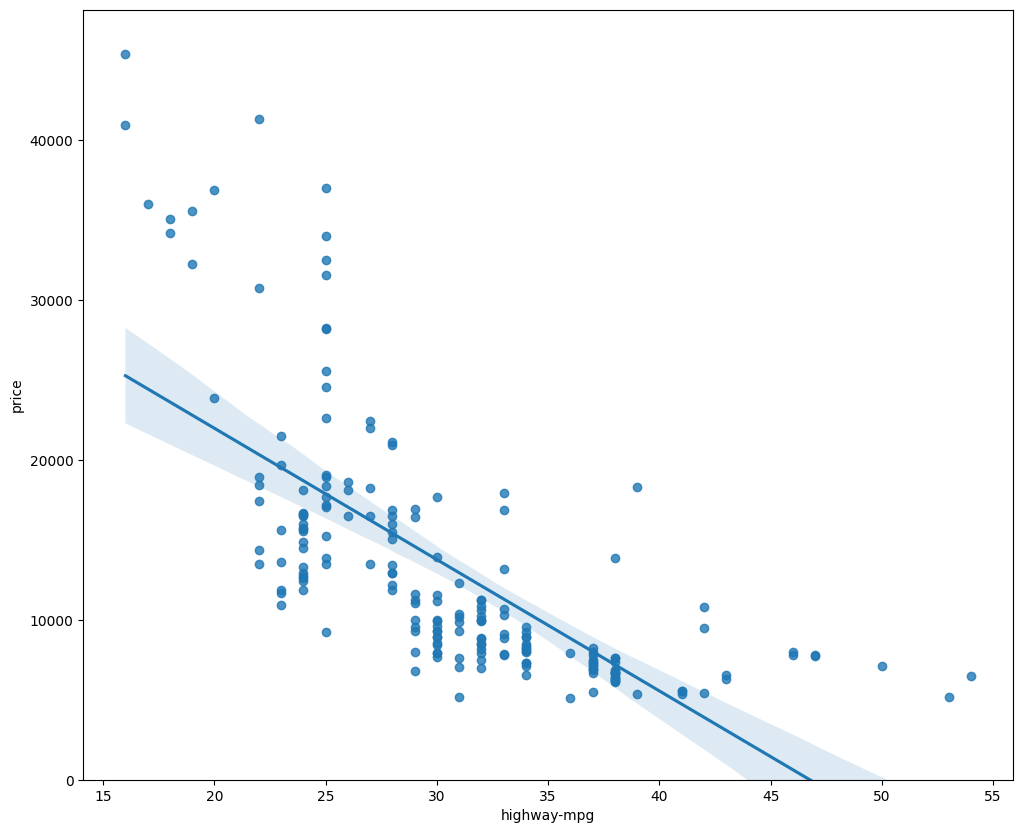

In [52]:
width =12
height = 10
plt.figure(figsize=(width, height))
sns.regplot(x="highway-mpg", y="price", data=df)
plt.ylim(0,)
plt.show()

<p>We can see from this plot that price is negatively correlated to highway-mpg since the regression slope is negative.

One thing to keep in mind when looking at a regression plot is to pay attention to how scattered the data points are around the regression line. This will give you a good indication of the variance of the data and whether a linear model would be the best fit or not. If the data is too far off from the line, this linear model might not be the best model for this data.

Let's compare this plot to the regression plot of "peak-rpm".</p>


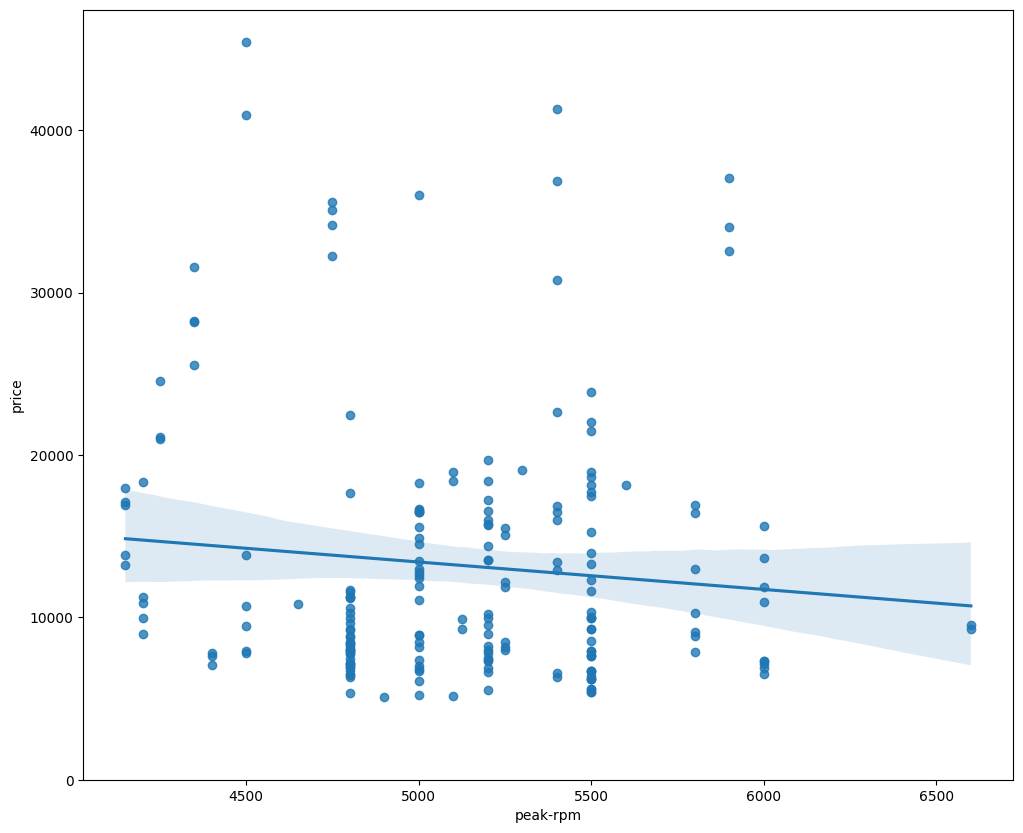

In [53]:
plt.figure(figsize=(width, height))
sns.regplot(x="peak-rpm", y="price", data=df)
plt.ylim(0,)
plt.show()

<p>Comparing the regression plot of "peak-rpm" and "highway-mpg", we see that the points for "highway-mpg" are much closer to the generated line and, on average, decrease. The points for "peak-rpm" have more spread around the predicted line and it is much harder to determine if the points are decreasing or increasing as the "peak-rpm" increases.</p>


In [54]:
df[["peak-rpm", "highway-mpg", "price"]].corr()

,peak-rpm,highway-mpg,price
peak-rpm,1.000000,-0.058598,-0.101616
highway-mpg,-0.058598,1.000000,-0.704692
price,-0.101616,-0.704692,1.000000


### Correlation Analysis

The correlation matrix shows the linear relationship between `peak-rpm`, `highway-mpg`, and `price`.

- `peak-rpm` and `price` have a **very weak negative correlation** (`r = -0.1016`), indicating that peak RPM has little influence on car price.
- `peak-rpm` and `highway-mpg` also exhibit a **very weak negative correlation** (`r = -0.0586`), suggesting almost no linear relationship.
- `highway-mpg` and `price` have a **strong negative correlation** (`r = -0.7047`), indicating that cars with higher highway fuel efficiency generally have lower prices, while cars with lower fuel efficiency tend to be more expensive.

Overall, `highway-mpg` is a much stronger predictor of `price` than `peak-rpm`.

<h3>Residual Plot</h3>

<p>A good way to visualize the variance of the data is to use a residual plot.</p>

<p>What is a <b>residual</b>?</p>

<p>The difference between the observed value (y) and the predicted value (Yhat) is called the residual (e). When we look at a regression plot, the residual is the distance from the data point to the fitted regression line.</p>

<p>So what is a <b>residual plot</b>?</p>

<p>A residual plot is a graph that shows the residuals on the vertical y-axis and the independent variable on the horizontal x-axis.</p>

<p>What do we pay attention to when looking at a residual plot?</p>

<p>We look at the spread of the residuals:</p>

<p>- If the points in a residual plot are <b>randomly spread out around the x-axis</b>, then a <b>linear model is appropriate</b> for the data.

Why is that? Randomly spread out residuals means that the variance is constant, and thus the linear model is a good fit for this data.</p>


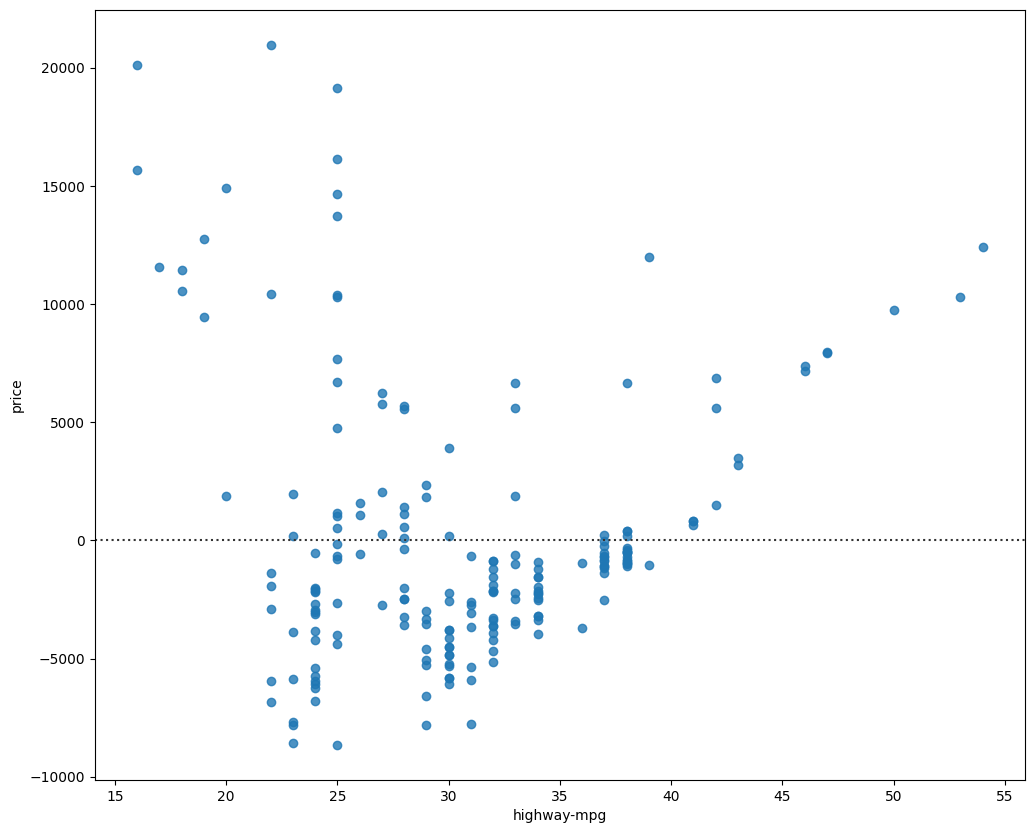

In [55]:
width = 12
height = 10
plt.figure(figsize=(width, height))
sns.residplot(x="highway-mpg", y="price", data=df)
plt.show()

### Residual Plot Interpretation

The residual plot displays the difference between the actual and predicted car prices against `highway-mpg`.

- The residuals are generally scattered around the horizontal zero line, indicating that a linear relationship exists between `highway-mpg` and `price`.
- However, a slight pattern or curvature in the residuals suggests that the relationship may not be perfectly linear.
- This indicates that while linear regression provides a reasonable fit, a polynomial regression model may better capture the relationship between `highway-mpg` and `price`.
- Overall, `highway-mpg` is a significant predictor of car price, but the residual plot suggests there is room for improving the model.

<h3>Multiple Linear Regression</h3>


<p>How do we visualize a model for Multiple Linear Regression? This gets a bit more complicated because you can't visualize it with regression or residual plot.</p>

<p>One way to look at the fit of the model is by looking at the <b>distribution plot</b>. We can look at the distribution of the fitted values that result from the model and compare it to the distribution of the actual values.</p>


First, let's make a prediction:


In [56]:
Y_hat = lm.predict(Z)

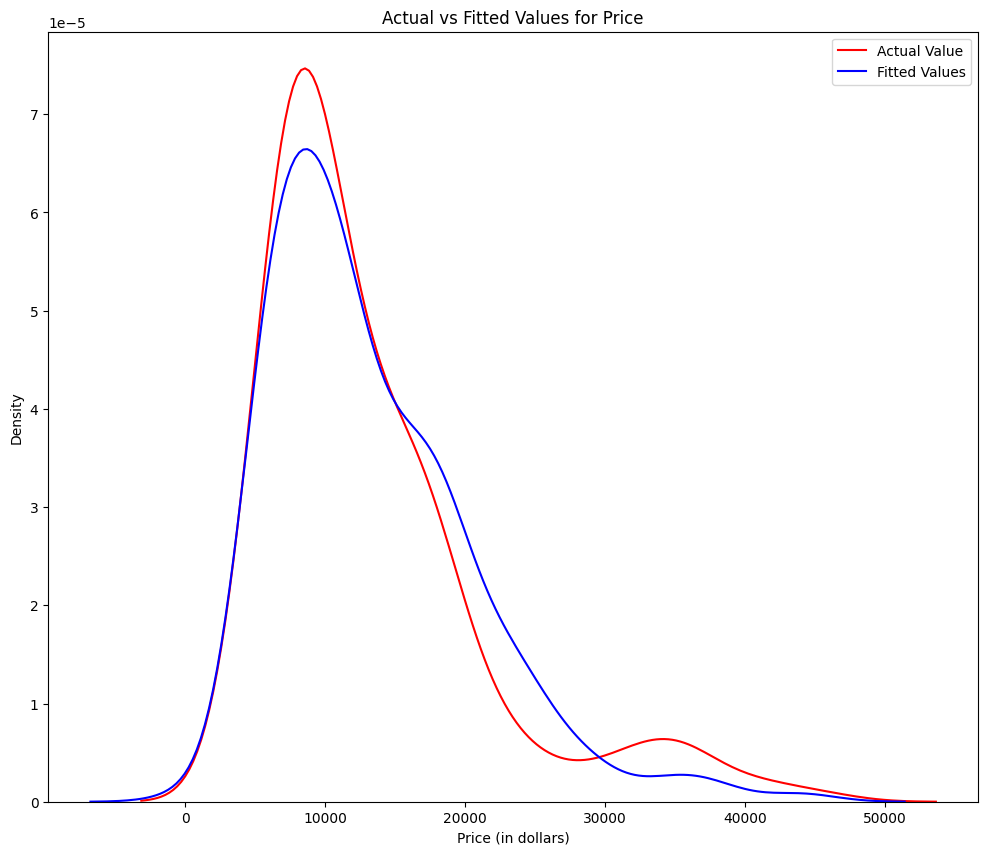

In [57]:
plt.figure(figsize=(width, height))

ax1 = sns.kdeplot(
    data=df['price'],
    color="r",
    label="Actual Value"
)

sns.kdeplot(
    data=Y_hat,
    color="b",
    label="Fitted Values",
    ax=ax1
)

plt.title("Actual vs Fitted Values for Price")
plt.xlabel("Price (in dollars)")
plt.ylabel("Density")   # Better label for KDE plots
plt.legend()

plt.show()
plt.close()

<p>We can see that the fitted values are reasonably close to the actual values since the two distributions overlap a bit. However, there is definitely some room for improvement.</p>


<h2>3. Polynomial Regression and Pipelines</h2>


<p><b>Polynomial regression</b> is a particular case of the general linear regression model or multiple linear regression models.</p> 
<p>We get non-linear relationships by squaring or setting higher-order terms of the predictor variables.</p>

<p>There are different orders of polynomial regression:</p>


<b>Quadratic - 2nd Order</b>
$$
Yhat = a + b_1 X +b_2 X^2 
$$


<b>Cubic - 3rd Order</b>
$$
Yhat = a + b_1 X +b_2 X^2 +b_3 X^3\\\\\\
$$

<b>Higher-Order</b>:
$$
Y = a + b_1 X +b_2 X^2 +b_3 X^3 ....\\
$$


<p>We saw earlier that a linear model did not provide the best fit while using "highway-mpg" as the predictor variable. Let's see if we can try fitting a polynomial model to the data instead.</p>


In [58]:
def PlotPolly(model, independent_variable, dependent_variable, Name) -> None:
    x_new = np.linspace(15, 55, 100)
    y_new = model(x_new)

    plt.plot(independent_variable, dependent_variable, '.', x_new, y_new, '-')
    plt.title('Polynomial Fit with Matplotlib for Price ~ Length')
    ax = plt.gca()
    ax.set_facecolor((0.898, 0.898, 0.898))
    fig = plt.gcf()
    plt.xlabel(Name)
    plt.ylabel('Price of Cars')

    plt.show()
    plt.close()

Let's get the variables:


In [59]:
x = df['highway-mpg']
y = df['price']

Let's fit the polynomial using the function <b>polyfit</b>, then use the function <b>poly1d</b> to display the polynomial function.


In [60]:
# Here we use a polynomial of 3rd order (cubic)
f = np.polyfit(x, y, 3)
p = np.poly1d(f)
print(p)

        3         2
-1.557 x + 204.8 x - 8965 x + 1.379e+05


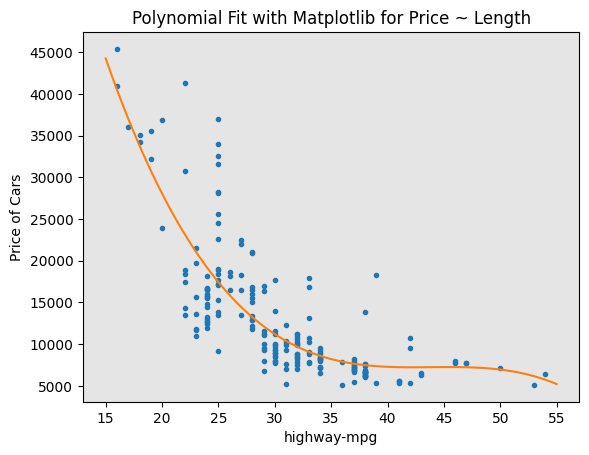

array([-1.55663829e+00,  2.04754306e+02, -8.96543312e+03,  1.37923594e+05])

In [61]:
PlotPolly(p, x, y, 'highway-mpg')
np.polyfit(x, y, 3)

            11             10             9           8         7
-1.243e-08 x  + 4.722e-06 x  - 0.0008028 x + 0.08056 x - 5.297 x
          6        5             4             3             2
 + 239.5 x - 7588 x + 1.684e+05 x - 2.565e+06 x + 2.551e+07 x - 1.491e+08 x + 3.879e+08


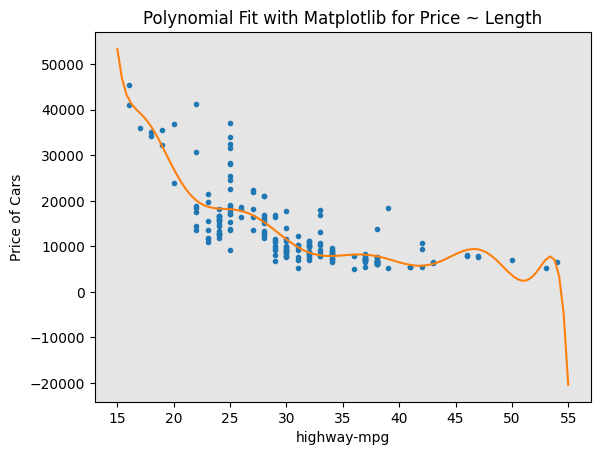

In [62]:
f1 = np.polyfit(x, y, 11)
p1 = np.poly1d(f1)
print(p1)
PlotPolly(p1, x, y, 'highway-mpg')

<p>The analytical expression for Multivariate Polynomial function gets complicated. For example, the expression for a second-order (degree=2) polynomial with two variables is given by:</p>


$$
Yhat = a + b_1 X_1 +b_2 X_2 +b_3 X_1 X_2+b_4 X_1^2+b_5 X_2^2
$$


We can perform a polynomial transform on multiple features. First, we import the module:


In [63]:
from sklearn.preprocessing import PolynomialFeatures

We create a <b>PolynomialFeatures</b> object of degree 2: 


In [64]:
pr=PolynomialFeatures(degree=2)
pr

PolynomialFeatures()

In [65]:
Z_pr=pr.fit_transform(Z)

In the original data, there are 201 samples and 4 features.


In [66]:
Z.shape

(201, 4)

After the transformation, there are 201 samples and 15 features.


In [67]:
Z_pr.shape

(201, 15)

<h2>Pipeline</h2>


<p>Data Pipelines simplify the steps of processing the data. We use the module <b>Pipeline</b> to create a pipeline. We also use <b>StandardScaler</b> as a step in our pipeline.</p>


In [68]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


We create the pipeline by creating a list of tuples including the name of the model or estimator and its corresponding constructor.


In [69]:
Input = [('scale', StandardScaler()), ('Polynomial', PolynomialFeatures(include_bias=False)),('model', LinearRegression())]

We input the list as an argument to the pipeline constructor

In [70]:
pipe = Pipeline(Input)
pipe

Pipeline(steps=[('scale', StandardScaler()),
                ('Polynomial', PolynomialFeatures(include_bias=False)),
                ('model', LinearRegression())])

First, we convert the data type Z to type float to avoid conversion warnings that may appear as a result of StandardScaler taking float inputs.

Then, we can normalize the data,  perform a transform and fit the model simultaneously. 


In [71]:
Z = Z.astype(float)
pipe.fit(Z,y)

Pipeline(steps=[('scale', StandardScaler()),
                ('Polynomial', PolynomialFeatures(include_bias=False)),
                ('model', LinearRegression())])

 Similarly,  we can normalize the data, perform a transform and produce a prediction  simultaneously.


In [72]:
ypipe = pipe.predict(Z)

In [73]:
result = pd.DataFrame({
        "Index"                 : df.index,
        "Highway-MPG"           : df['highway-mpg'],
        "Horsepower"            : df['horsepower'],
        "Curb-weight"           :df['curb-weight'],
        "Engine-size"           :df['engine-size'],
        "Actual Price"          : df['price'],
        "Predicted Price"       : ypipe,
        "Diference"             : df['price'] - ypipe
})

In [74]:
result

,Index,Highway-MPG,Horsepower,Curb-weight,Engine-size,Actual Price,Predicted Price,Diference
0,0,27,111.0,2548,130,13495.0,13102.747842,392.252158
1,1,27,111.0,2548,130,16500.0,13102.747842,3397.252158
2,2,26,154.0,2823,152,16500.0,18225.545722,-1725.545722
3,3,30,102.0,2337,109,13950.0,10390.296366,3559.703634
4,4,22,115.0,2824,136,17450.0,16136.296192,1313.703808
...,...,...,...,...,...,...,...,...
196,196,28,114.0,2952,141,16845.0,14749.229289,2095.770711
197,197,25,160.0,3049,141,19045.0,18027.490721,1017.509279
198,198,23,134.0,3012,173,21485.0,19827.656418,1657.343582
199,199,27,106.0,3217,145,22470.0,17324.329825,5145.670175


In [75]:
mse = mean_squared_error(y,ypipe)
print(mse)

9656613.4039896


In [76]:
r2 = r2_score(y,ypipe)
print(r2)

0.8463341969864728


<b>Create a pipeline that standardizes the data, then produce a prediction using a linear regression model using the features Z and target y.</b>
</div>

In [77]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
Input = [('scale', StandardScaler()), ('model', LinearRegression())]
pipe = Pipeline(Input)
pipe.fit(Z,y)
y_pipe = pipe.predict(Z)
y_pipe[0:10]

array([13699.11161184, 13699.11161184, 19051.65470233, 10620.36193015,
       15521.31420211, 13869.66673213, 15456.16196732, 15974.00907672,
       17612.35917161, 10722.32509097])

<h2>4. Measures for In-Sample Evaluation</h2>


<p>When evaluating our models, not only do we want to visualize the results, but we also want a quantitative measure to determine how accurate the model is.</p>

<p>Two very important measures that are often used in Statistics to determine the accuracy of a model are:</p>
<ul>
    <li><b>R^2 / R-squared</b></li>
    <li><b>Mean Squared Error (MSE)</b></li>
</ul>
    
<b>R-squared</b>

<p>R squared, also known as the coefficient of determination, is a measure to indicate how close the data is to the fitted regression line.</p>
    
<p>The value of the R-squared is the percentage of variation of the response variable (y) that is explained by a linear model.</p>



<b>Mean Squared Error (MSE)</b>

<p>The Mean Squared Error measures the average of the squares of errors. That is, the difference between actual value (y) and the estimated value (ŷ).</p>


<h3>Model 1: Simple Linear Regression</h3>


Let's calculate the R^2:


In [78]:
#highway_mpg_fit
lm.fit(X, Y)
# Find the R^2
print('The R-square is: ', lm.score(X, Y))

The R-square is:  0.7609686443622008


In [79]:
Yhat=lm.predict(X)
print('The output of the first four predicted value is: ', Yhat[0:4])

The output of the first four predicted value is:  [13728.4631336  13728.4631336  17399.38347881 10224.40280408]


In [80]:
from sklearn.metrics import mean_squared_error

We can compare the predicted results with the actual results:


In [81]:
mse = mean_squared_error(df['price'], Yhat)
print('The mean square error of price and predicted value is: ', mse)

The mean square error of price and predicted value is:  15021126.02517414



<h3>Model 2: Multiple Linear Regression</h3>



Let's calculate the R^2:


In [82]:
# fit the model 
lm.fit(Z, df['price'])
# Find the R^2
print('The R-square is: ', lm.score(Z, df['price']))

The R-square is:  0.8093562806577457


We can say that ~80.896 % of the variation of price is explained by this multiple linear regression "multi_fit".


Let's calculate the MSE.


In [83]:
Y_predict_multifit = lm.predict(Z)

In [84]:
print('The mean square error of price and predicted value using multifit is: ', \
      mean_squared_error(df['price'], Y_predict_multifit))

The mean square error of price and predicted value using multifit is:  11980366.87072649


<h3>Model 3: Polynomial Fit</h3>


Let's calculate the R^2.


Let’s import the function <b>r2_score</b> from the module <b>metrics</b> as we are using a different function.


In [85]:
from sklearn.metrics import r2_score

We apply the function to get the value of R^2:


In [86]:
r_squared = r2_score(y, p(x))
print('The R-square value is: ', r_squared)

The R-square value is:  0.6741946663906517


We can say that ~67.419 % of the variation of price is explained by this polynomial fit.


<h3>MSE</h3>


We can also calculate the MSE:  


In [87]:
mean_squared_error(df['price'], p(x))

20474146.42636122

<h2>5. Prediction and Decision Making</h2>
<h3>Prediction</h3>

<p>In the previous section, we trained the model using the method <b>fit</b>. Now we will use the method <b>predict</b> to produce a prediction. Lets import <b>pyplot</b> for plotting; we will also be using some functions from numpy.</p>


In [88]:
import matplotlib.pyplot as plt
import numpy as np


In [89]:
new_input = np.arange(1,101,1).reshape(-1,1)

In [90]:
lm.fit(X,Y)
lm

LinearRegression()

In [91]:
yhat = lm.predict(new_input)
yhat[0:5]

/Users/rahulkpkurup/Learning/Git-Portfolio/Professional-Course/IBM GenAI Engineering/.env/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([-7796.47889059, -7629.6188749 , -7462.75885921, -7295.89884352,
       -7129.03882782])

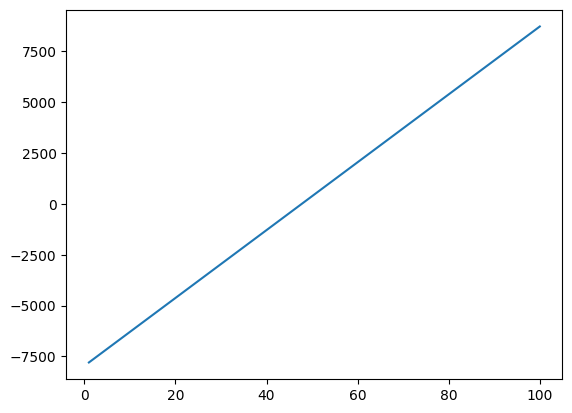

In [92]:
plt.plot(new_input, yhat)
plt.show()

<h3>Decision Making: Determining a Good Model Fit</h3>


<p>Now that we have visualized the different models, and generated the R-squared and MSE values for the fits, how do we determine a good model fit?
<ul>
    <li><i>What is a good R-squared value?</i></li>
</ul>
</p>

<p>When comparing models, <b>the model with the higher R-squared value is a better fit</b> for the data.
<ul>
    <li><i>What is a good MSE?</i></li>
</ul>
</p>

<p>When comparing models, <b>the model with the smallest MSE value is a better fit</b> for the data.</p>


<h4>Let's take a look at the values for the different models.</h4>
<p>Simple Linear Regression: Using Highway-mpg as a Predictor Variable of Price.
<ul>
    <li>R-squared: 0.49659118843391759</li>
    <li>MSE: 3.16 x10^7</li>
</ul>
</p>
    
<p>Multiple Linear Regression: Using Horsepower, Curb-weight, Engine-size, and Highway-mpg as Predictor Variables of Price.
<ul>
    <li>R-squared: 0.80896354913783497</li>
    <li>MSE: 1.2 x10^7</li>
</ul>
</p>
    
<p>Polynomial Fit: Using Highway-mpg as a Predictor Variable of Price.
<ul>
    <li>R-squared: 0.6741946663906514</li>
    <li>MSE: 2.05 x 10^7</li>
</ul>
</p>


<h3>Simple Linear Regression Model (SLR) vs Multiple Linear Regression Model (MLR)</h3>


<p>Usually, the more variables you have, the better your model is at predicting, but this is not always true. Sometimes you may not have enough data, you may run into numerical problems, or many of the variables may not be useful and even act as noise. As a result, you should always check the MSE and R^2.</p>

<p>In order to compare the results of the MLR vs SLR models, we look at a combination of both the R-squared and MSE to make the best conclusion about the fit of the model.
<ul>
    <li><b>MSE</b>: The MSE of SLR is  3.16x10^7  while MLR has an MSE of 1.2 x10^7.  The MSE of MLR is much smaller.</li>
    <li><b>R-squared</b>: In this case, we can also see that there is a big difference between the R-squared of the SLR and the R-squared of the MLR. The R-squared for the SLR (~0.497) is very small compared to the R-squared for the MLR (~0.809).</li>
</ul>
</p>

This R-squared in combination with the MSE show that MLR seems like the better model fit in this case compared to SLR.


<h3>Simple Linear Model (SLR) vs. Polynomial Fit</h3>


<ul>
    <li><b>MSE</b>: We can see that Polynomial Fit brought down the MSE, since this MSE is smaller than the one from the SLR.</li> 
    <li><b>R-squared</b>: The R-squared for the Polynomial Fit is larger than the R-squared for the SLR, so the Polynomial Fit also brought up the R-squared quite a bit.</li>
</ul>
<p>Since the Polynomial Fit resulted in a lower MSE and a higher R-squared, we can conclude that this was a better fit model than the simple linear regression for predicting "price" with "highway-mpg" as a predictor variable.</p>


<h3>Multiple Linear Regression (MLR) vs. Polynomial Fit</h3>


<ul>
    <li><b>MSE</b>: The MSE for the MLR is smaller than the MSE for the Polynomial Fit.</li>
    <li><b>R-squared</b>: The R-squared for the MLR is also much larger than for the Polynomial Fit.</li>
</ul>


<h2>Conclusion</h2>


<p>Comparing these three models, we conclude that <b>the MLR model is the best model</b> to be able to predict price from our dataset. This result makes sense since we have 27 variables in total and we know that more than one of those variables are potential predictors of the final car price.</p>
